In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [2]:
df = pd.read_csv("Google_Stock_Price_Train.csv")

df = df.head(1000)

df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [3]:
data = df.iloc[:,1:2].values

data.shape

(1000, 1)

In [4]:
scaler = MinMaxScaler(feature_range=(0,1))

data_sc = scaler.fit_transform(data)

In [5]:
def create_sequences(data, seq_len=60):
    x = []
    y = []

    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i])
        y.append(data[i])

    return np.array(x), np.array(y)

In [6]:
X, y = create_sequences(data_sc)

X.shape

(940, 60, 1)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [8]:
model = Sequential()

model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

C:\Users\soham\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [10]:
model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0557
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0216 
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0129 
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0118
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0088


In [11]:
predicted_stock_price = model.predict(X_test)

predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

real_stock_price = scaler.inverse_transform(y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step 


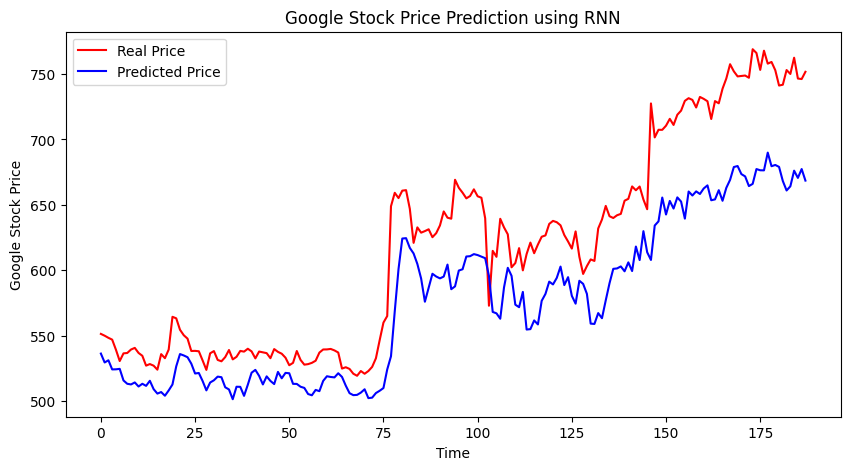

In [12]:
plt.figure(figsize=(10,5))

plt.plot(real_stock_price, color='red', label='Real Price')

plt.plot(predicted_stock_price, color='blue', label='Predicted Price')

plt.title('Google Stock Price Prediction using RNN')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()

In [13]:
rmse = np.sqrt(mean_squared_error(real_stock_price, predicted_stock_price))

print("RMSE:", rmse)

RMSE: 48.99476493382999
